# 📓 Cas d'usage IA — Marketing bancaire

**Auteur·e** : Jérémy Calvo
**Promo** : Dev-id — Parcours 2 (Pros IT)
**Date début** : 29/09/2026
**Dernière mise à jour** : 29/09/2026


## 0. Imports & configuration

In [1]:
# Imports standards
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Reproductibilité
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Affichage
pd.set_option("display.max_columns", 100)


## 0.5 Traçabilité de la session

In [2]:
import hashlib
import platform
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import sklearn
import matplotlib
import seaborn

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "bank-additional-full.csv").exists():
            return candidate
    raise FileNotFoundError("Racine du repo introuvable (data/bank-additional-full.csv)")


REPO_ROOT = find_repo_root()
DATA_PATH = REPO_ROOT / "data" / "bank-additional-full.csv"


def sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()


def git_commit() -> str:
    try:
        return subprocess.check_output(
            ["git", "rev-parse", "--short", "HEAD"], text=True
        ).strip()
    except Exception:
        return "n/a"


DATASET_VERSION = {
    "name": "UCI Bank Marketing — bank-additional-full.csv",
    "source": "https://archive.ics.uci.edu/dataset/222/bank+marketing",
    "extracted_at": "JJ/MM/AAAA",  # à compléter (date d'extraction du CSV)
    "sha256": sha256(DATA_PATH),
    "n_rows": 41188,
    "n_cols": 21,
    "separator": ";",
}

ENV_VERSIONS = {
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "scikit-learn": sklearn.__version__,
    "matplotlib": matplotlib.__version__,
    "seaborn": seaborn.__version__,
}

print("Dataset :", DATASET_VERSION)
print("Environnement :", ENV_VERSIONS)
print("Commit Git :", git_commit())


Dataset : {'name': 'UCI Bank Marketing — bank-additional-full.csv', 'source': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'extracted_at': 'JJ/MM/AAAA', 'sha256': '74adfc578bf77a7ff4bb1ba4a9f8709d9e3c6907342959c2c8416847e0afb4d8', 'n_rows': 41188, 'n_cols': 21, 'separator': ';'}
Environnement : {'python': '3.12.3', 'pandas': '2.3.3', 'numpy': '2.4.6', 'scikit-learn': '1.9.0', 'matplotlib': '3.11.1', 'seaborn': '0.13.2'}
Commit Git : f73a6d1


---
## 1. Cadrage métier & problème

### 1.1 Contexte client

Le client est une **banque de détail** qui propose à ses clients des produits d'épargne, notamment des **dépôts à terme**. Pour les commercialiser, elle mène des **campagnes de démarchage téléphonique** : des conseillers appellent des clients pour leur proposer le produit.

Ces campagnes ont un **coût élevé** (temps des conseillers, plateformes d'appels). Mal ciblées, elles **saturent les clients d'appels non pertinents** et **dégradent la relation commerciale**. Le client veut donc **concentrer l'effort sur les bons profils**, **réduire les appels inutiles** et **améliorer l'expérience client**.

Le recours à l'IA est motivé par la volonté d'**estimer en amont la probabilité de souscription** à partir du profil et de l'historique des contacts. L'enjeu n'est pas seulement technique : démarcher sur la base de données personnelles (âge, profession, situation familiale, niveau d'éducation) soulève des **questions d'équité, de conformité RGPD et de pratiques commerciales acceptables**.


### 1.2 Énoncé du problème IA

**Tâche** : classification binaire supervisée.

- **Entrées (X)** : caractéristiques du client et de l'historique des contacts, **disponibles avant l'issue de la campagne**.
- **Cible (y)** : `y ∈ {oui, non}` — le client a-t-il souscrit un dépôt à terme ?
- **Sortie opérationnelle** : une **probabilité de souscription** (score entre 0 et 1), utilisée pour **prioriser** les clients à appeler — **pas** une décision automatique de démarchage.


### 1.3 Bénéficiaires & impacts

| Type | Acteur | Bénéfice / impact |
|---|---|---|
| Direct | Conseillers | Appels mieux ciblés, moins de temps perdu. |
| Direct | Responsable de campagne | Meilleure allocation de l'effort, pilotage par la probabilité. |
| Indirect | Clients | Moins d'appels non pertinents (meilleure expérience) ; **risque d'être écarté du démarchage** par le modèle. |
| Indirect | Banque | Meilleur taux de conversion, **risque réputationnel/juridique** si ciblage discriminant ou non conforme. |

> **Point de vigilance** : un modèle qui prédit mal pour un sous-groupe peut **priver ce groupe d'une opportunité commerciale** (moins sollicité) ou le **sur-solliciter**.


### 1.4 Critères de succès

| Type | Critère | Cible initiale (client) | Justification |
|---|---|---|---|
| Métier | Taux de conversion des clients contactés | Améliorer vs ciblage aléatoire | Concentrer l'effort sur les profils les plus réceptifs. |
| Modèle | Rappel sur la classe « oui » (classe minoritaire) | Priorité au rappel | Rater un souscripteur = un appel potentiel manqué. |
| Modèle | F1-score classe « oui » | ≥ 0.50 (ordre de grandeur) | Équilibre rappel / précision sur la classe positive. |
| Modèle | ROC-AUC | ≥ 0.75 (ordre de grandeur) | Capacité d'ordonnancement, indépendante du seuil. |
| Opérationnel | Latence de réponse API | < 500 ms | Interrogation avant appel par un conseiller. |
| Opérationnel | Disponibilité du service | > 99 % | Usage courant en agence. |


### 1.5 Risques éthiques & réglementaires anticipés

**Données personnelles (RGPD)**
- Le jeu contient des **données personnelles** : socio-démographiques (`age`, `job`, `marital`, `education`), situation bancaire (`default`, `housing`, `loan`) et historique de contact.
- **Article 9 (catégories particulières)** : a priori **aucune** donnée de santé / religion / origine / orientation sexuelle **au sens strict**. Mais `marital`, `job` et `education` peuvent **révéler indirectement** des situations sensibles et servent un **ciblage commercial** → sensibilité **éthique** à documenter.
- **Base légale** : à **confirmer avec le DPO** (piste prudente : intérêt légitime et/ou consentement), **non présumée acquise**.
- **Obligations** : information des personnes, **minimisation**, **durée de conservation** limitée.

**Biais & équité**
- Risque de **discrimination indirecte** via un ciblage fondé sur l'âge, la profession, la situation familiale, l'éducation.

**Fuite d'information (leakage)**
- `duration` (durée du dernier appel) n'est connue qu'**une fois l'appel terminé** : l'utiliser pour décider *qui appeler en amont* constitue une **fuite d'information**.


### 1.6 📝 Synthèse cadrage

- **Problème** : estimer la probabilité qu'un client souscrive à un dépôt à terme, pour cibler les campagnes de démarchage téléphonique.
- **Tâche IA** : classification binaire supervisée (cible `y`), sortie = **probabilité** (aide à la priorisation), pas une décision automatique.
- **Critère de succès dominant** : performance sur la **classe minoritaire « oui »** (rappel / F1 / ROC-AUC), en tenant compte du coût d'un appel inutile.
- **Principal risque** : discrimination indirecte via des variables sensibles + conformité RGPD à cadrer avec le DPO.


---
## 2. Identification & acquisition des données

### 2.1 Sources

Le jeu de données provient du **UCI Machine Learning Repository** (Bank Marketing). Il est issu d'une campagne de démarchage téléphonique d'une **banque portugaise** et est fourni sous forme d'un fichier CSV au séparateur point-virgule.

| Source | Type | Volumétrie | Format | Accès | Date extraction |
|---|---|---|---|---|---|
| UCI ML Repository — Bank Marketing | Jeu de données public | 41 188 lignes × 21 colonnes | CSV (`;`) | Lecture seule (fichier local) | `JJ/MM/AAAA` |


In [3]:
df = pd.read_csv(DATA_PATH, sep=";")

print("Dimensions :", df.shape)
print("\nColonnes :", df.columns.tolist())
print("\nTypes :")
print(df.dtypes)

df.head(3)


Dimensions : (41188, 21)

Colonnes : ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

Types :
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### 2.3 Dictionnaire de variables

Trois colonnes de qualification sont distinguées : **donnée personnelle** (au sens du RGPD), **catégorie particulière** (article 9) et **variable sensible pour le ciblage commercial** (critère de discrimination possible ou jugement éthique).

| Variable | Description | Type | Plage / valeurs | Cible ? | Donnée perso ? | Art. 9 ? | Sensible ciblage ? |
|---|---|---|---|---|---|---|---|
| `age` | Âge du client | num | 17 – 98 | non | oui | non | oui |
| `job` | Type d'emploi | cat | admin., blue-collar, entrepreneur, housemaid, management, retired, self-employed, services, student, technician, unemployed, unknown | non | oui | non | oui |
| `marital` | Statut marital | cat | married, single, divorced, unknown | non | oui | non | oui |
| `education` | Niveau d'éducation | cat | basic.4y, basic.6y, basic.9y, high.school, illiterate, professional.course, university.degree, unknown | non | oui | non | oui |
| `default` | Crédit en défaut de paiement | cat | yes, no, unknown | non | oui | non | non |
| `housing` | Prêt immobilier | cat | yes, no, unknown | non | oui | non | non |
| `loan` | Prêt personnel | cat | yes, no, unknown | non | oui | non | non |
| `contact` | Moyen de contact | cat | cellular, telephone | non | oui | non | non |
| `month` | Mois du dernier contact | cat | jan … dec | non | oui | non | non |
| `day_of_week` | Jour de la semaine du dernier contact | cat | mon … fri | non | oui | non | non |
| `duration` | Durée du dernier contact (secondes) | num | 0 – 4 918 | non | oui | non | non |
| `campaign` | Nombre de contacts durant cette campagne | num | 1 – 56 | non | oui | non | non |
| `pdays` | Jours depuis le dernier contact d'une campagne précédente | num | 0 – 999 (999 = jamais recontacté) | non | oui | non | non |
| `previous` | Nombre de contacts avant cette campagne | num | 0 – 7 | non | oui | non | non |
| `poutcome` | Résultat de la campagne précédente | cat | failure, nonexistent, success | non | oui | non | non |
| `emp.var.rate` | Taux de variation de l'emploi | num | -3,4 – 1,4 | non | non | non | non |
| `cons.price.idx` | Indice des prix à la consommation | num | 92,2 – 94,8 | non | non | non | non |
| `cons.conf.idx` | Indice de confiance des consommateurs | num | -50,8 – -26,9 | non | non | non | non |
| `euribor3m` | Taux Euribor 3 mois | num | 0,63 – 5,05 | non | non | non | non |
| `nr.employed` | Nombre de salariés | num | 4 963,6 – 5 228,1 | non | non | non | non |
| `y` | Le client a-t-il souscrit un dépôt à terme ? | cat | yes, no | **oui** | oui | non | — |

> Aucune variable ne relève d'une **catégorie particulière** au sens de l'article 9 du RGPD. En revanche, `age`, `job`, `marital` et `education` sont des **critères de discrimination** possibles et doivent être surveillés dans un usage de ciblage commercial.

### 2.4 📝 Synthèse acquisition

- **Origine** : jeu public UCI Bank Marketing, campagne d'une banque portugaise ; aucune valeur manquante au sens strict (pas de `NaN`).
- **Volumétrie** : 41 188 observations, 20 variables explicatives et une cible binaire `y`.
- **Qualité apparente** : 12 lignes dupliquées ; des modalités `unknown` sur `job`, `marital`, `education`, `default`, `housing`, `loan` ; la valeur `999` de `pdays` est une sentinelle (« jamais recontacté »).
- **Données personnelles** : toutes les variables décrivant le client ou ses contacts ; les cinq indicateurs macro-économiques ne le sont pas.
- **Variables sensibles pour le ciblage** : `age`, `job`, `marital`, `education`.


---
## 3. Exploration & analyse des données (EDA)

Objectif : comprendre la donnée avant de la transformer — qualité, distributions, déséquilibre de la cible et écarts entre groupes.


In [ ]:
# 3.1 Premier coup d'œil
print("Dimensions :", df.shape)
df.info()

df.head()


In [ ]:
# Statistiques descriptives (numériques + catégorielles)
df.describe(include="all").T


In [ ]:
# 3.2 Qualité des données

# Valeurs manquantes au sens strict
print("Valeurs manquantes :", int(df.isna().sum().sum()))

# Doublons exacts
print("Lignes dupliquées :", int(df.duplicated().sum()))

# Modalités "unknown" (valeurs présentes, non manquantes)
print("\nModalités 'unknown' par variable :")
for col in df.select_dtypes(include="object").columns:
    n = int((df[col] == "unknown").sum())
    if n:
        print(f"  {col} : {n}")

# Sentinelle pdays = 999 ("jamais recontacté")
print("\npdays = 999 :", int((df["pdays"] == 999).sum()), "lignes")


**Doublons.** Le fichier ne contient **aucun identifiant client**. Les 12 lignes dupliquées sont **identiques sur les 21 colonnes**, mais on ne peut pas déterminer s'il s'agit d'un même client enregistré deux fois ou de deux clients distincts partageant exactement le même profil et le même contact. Constat à ce stade : **12 lignes strictement identiques**, sans clé permettant de trancher. Le traitement sera décidé plus tard.


Task was destroyed but it is pending!
task: <Task pending name='Task-303' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/jcalvo/.local/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-304' coro=<Kernel.shell_main() running at /home/jcalvo/.local/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/jcalvo/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
/home/jcalvo/.local/lib/python3.12/site-packages/matplotlib/_api/__init__.py:188: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  def check_in_list(values, /, **kwargs):
Task was destroyed but it is pending!
task: <Task pending name='Task-304' coro=<Kernel.shell_main() running at /home/jcalvo/.local/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


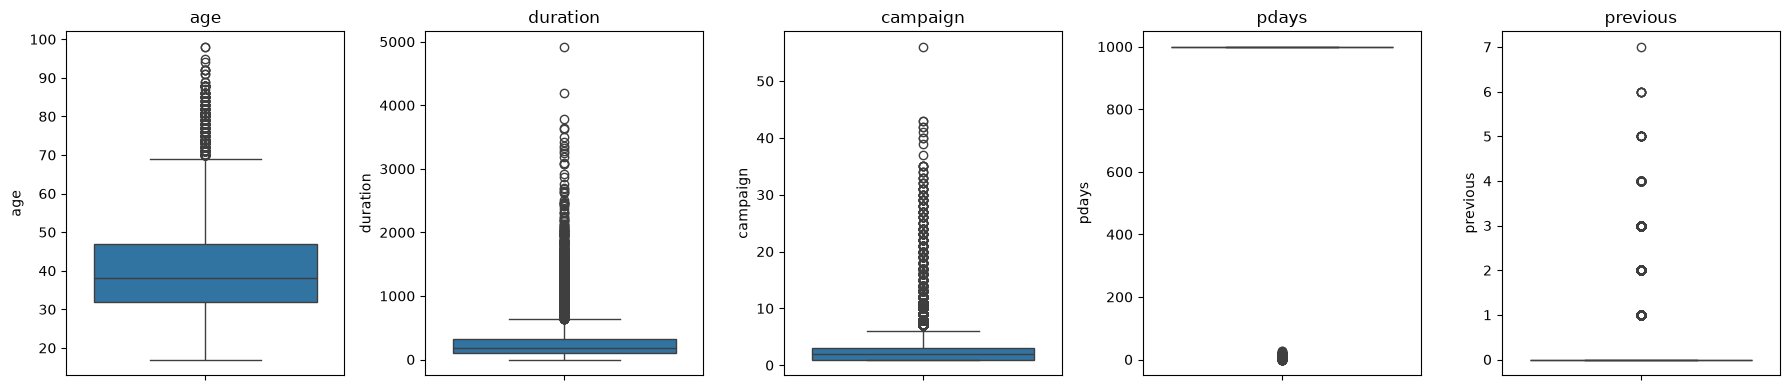

In [28]:
# Valeurs extrêmes des variables numériques (visualisation, pas de suppression)
num_cols = ["age", "duration", "campaign", "pdays", "previous"]

fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


Lecture : `age` est resserré autour de la quarantaine avec quelques âges élevés ; `duration` et `campaign` sont très étalés avec des valeurs extrêmes ; `pdays` est écrasé par la sentinelle 999 (la boîte est invisible) ; `previous` est presque toujours à 0. Ces extrêmes sont conservés tels quels à ce stade.

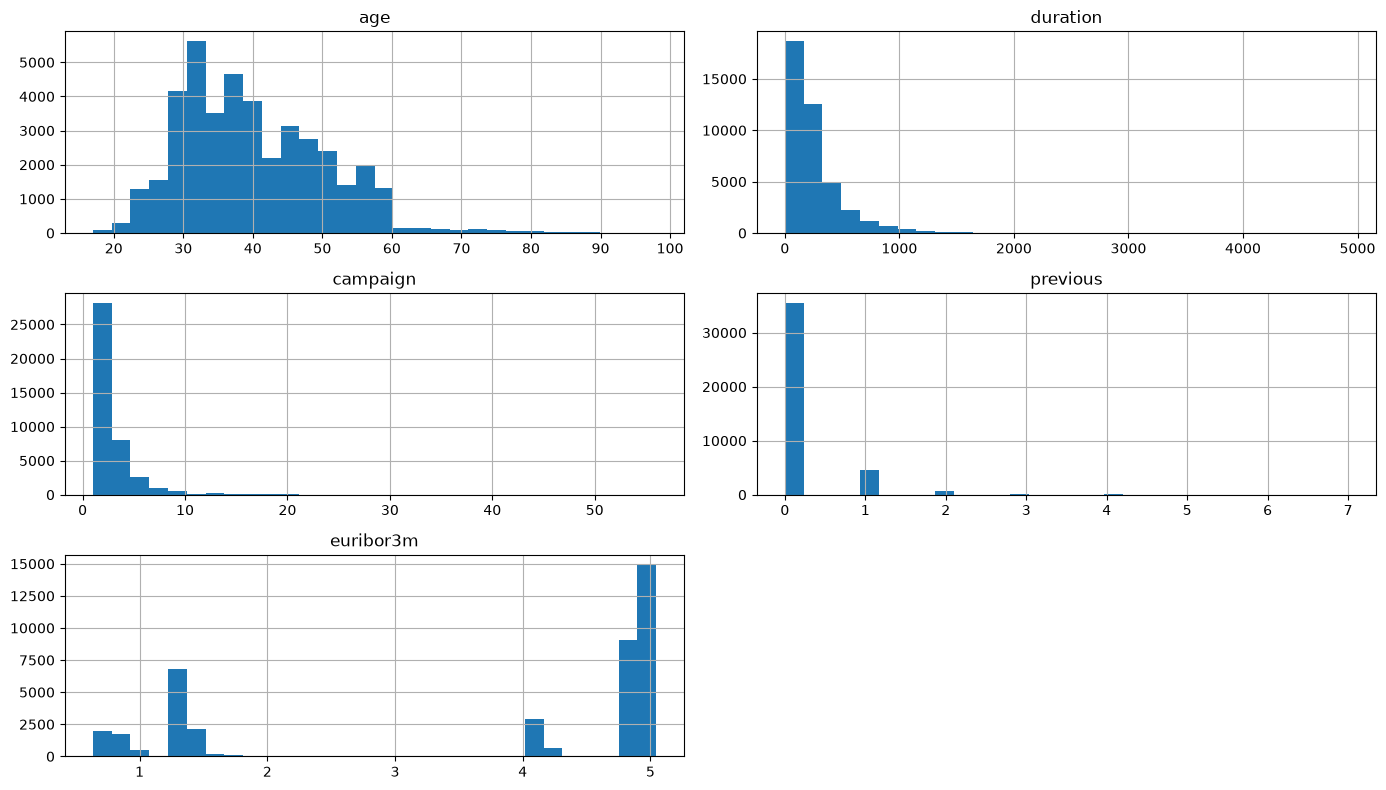

In [29]:
# 3.3 Distribution des variables

# Numériques
num_to_plot = ["age", "duration", "campaign", "previous", "euribor3m"]
df[num_to_plot].hist(bins=30, figsize=(14, 8))
plt.tight_layout()
plt.show()


Lecture : `age` est proche d'une cloche centrée vers 35-40 ans ; `duration` et `campaign` sont fortement asymétriques (majorité de valeurs faibles, longue traîne) ; `previous` est massivement à 0 ; `euribor3m` se répartit en deux zones (taux bas et taux élevés), reflet des périodes macroéconomiques.

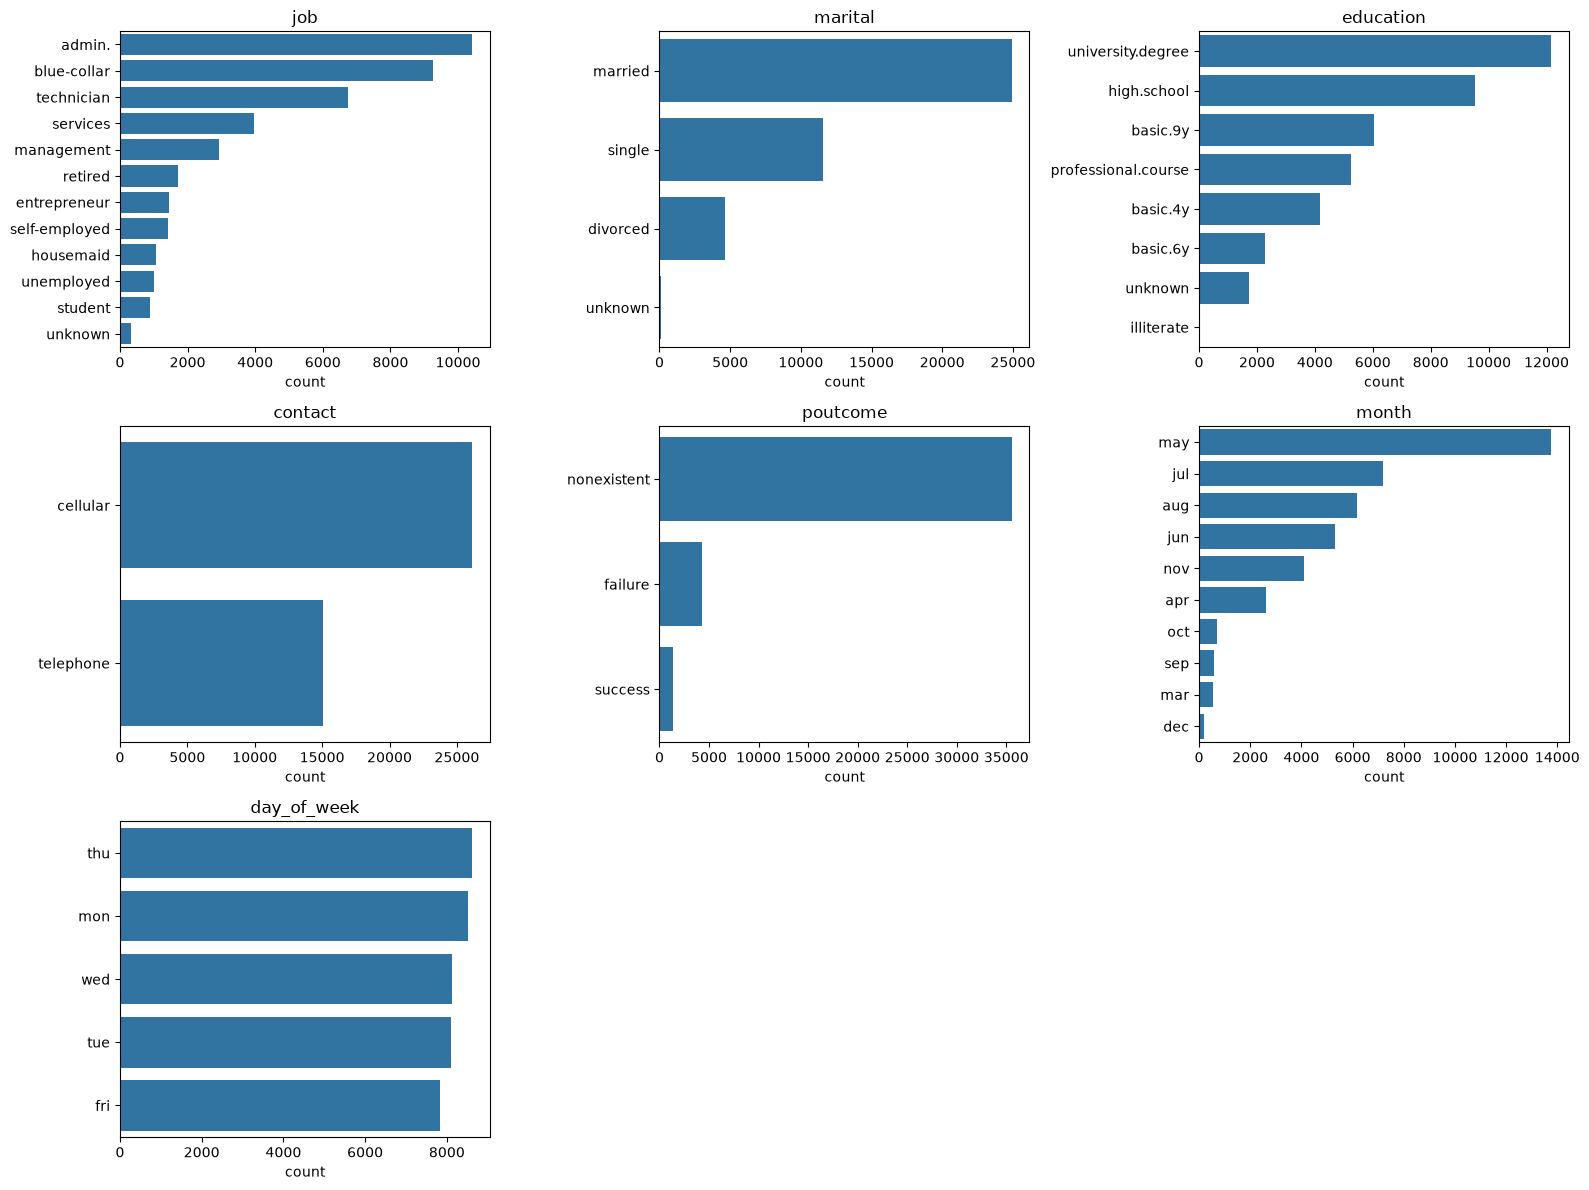

In [30]:
# Catégorielles
cat_cols = ["job", "marital", "education", "contact", "poutcome", "month", "day_of_week"]
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.ravel(), cat_cols):
    sns.countplot(data=df, y=col, order=df[col].value_counts().index, ax=ax)
    ax.set_title(col)
    ax.set_ylabel("")
for ax in axes.ravel()[len(cat_cols):]:
    ax.axis("off")
plt.tight_layout()
plt.show()


Lecture : les effectifs sont très inégaux selon les modalités. `job` est dominé par admin., blue-collar et technician ; `marital` par married ; `education` par university.degree ; `contact` par cellular ; `poutcome` par nonexistent (peu de clients réellement recontactés) ; `month` est concentré sur mai ; `day_of_week` est réparti de façon homogène.

In [ ]:
# 3.4 Variable cible : équilibre des classes
print(df["y"].value_counts())
print()
print(df["y"].value_counts(normalize=True).round(4))

sns.countplot(data=df, x="y")
plt.title("Répartition de la cible y")
plt.show()


Lecture : la cible est nettement déséquilibrée, avec environ 11 % de `yes` contre 89 % de `no`. Un modèle qui prédirait toujours `no` aurait une exactitude élevée mais serait inutile.

In [ ]:
# 3.5 Corrélations entre variables numériques
corr = df.select_dtypes(exclude="object").corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Corrélations (Pearson) entre variables numériques")
plt.show()


Lecture : les indicateurs macroéconomiques (`emp.var.rate`, `euribor3m`, `nr.employed`) sont très fortement corrélés entre eux (≈ 0,9+) et portent une information largement redondante ; `pdays` et `previous` sont liés négativement (−0,59). Les variables socio-démographiques (`age`) sont peu corrélées aux indicateurs macro.

In [ ]:
# 3.6 Analyse des biais & variables sensibles

# Taux de sélection = part de clients ayant souscrit, par groupe
# Disparate impact (règle des 4/5) = taux_min / taux_max


def selection_rate_table(frame, col):
    sr = frame.groupby(col, observed=True)["y"].apply(lambda s: (s == "yes").mean())
    support = frame[col].value_counts()
    table = pd.DataFrame({
        "taux_souscription": (sr * 100).round(1),
        "support": support,
    }).sort_values("taux_souscription")
    di = sr.min() / sr.max()
    verdict = "signal 4/5" if di < 0.8 else "pas de signal 4/5"
    print(f"\n=== {col} — DI = {di:.3f} ({verdict}) ===")
    display(table)


df["age_bin"] = pd.cut(
    df["age"], bins=[16, 25, 35, 45, 55, 65, 100],
    labels=["17-25", "26-35", "36-45", "46-55", "56-65", "66+"],
)

for col in ["age_bin", "job", "marital", "education"]:
    selection_rate_table(df, col)


**Lecture des écarts.** Les taux de souscription historiques varient fortement selon les groupes :

- **Âge** : `66+` (46,8 %) et `17-25` (20,9 %) souscrivent bien plus que `36-45` (8,5 %) ; DI ≈ 0,18 → signal marqué.
- **Profession** : `student` (31,4 %) et `retired` (25,2 %) contre `blue-collar` (6,9 %) ; DI ≈ 0,22 → signal marqué.
- **Situation familiale** : `single` (14,0 %) et `unknown` (15,0 %) contre `married` (10,2 %) ; DI ≈ 0,68 → sous le seuil 0,8, signal modéré.
- **Éducation** : `illiterate` (22,2 %) et `university.degree` (13,7 %) contre `basic.9y` (7,8 %) ; DI ≈ 0,35 → signal marqué.

Ces chiffres décrivent les **données historiques**, pas un modèle : ils montrent que les taux de sélection sont déjà inégaux selon les groupes. À noter, deux groupes ont un **support très faible** (`illiterate` : 18 clients, `marital=unknown` : 80) : leur taux est peu fiable. Aucune conclusion définitive à ce stade, seulement des écarts à surveiller.


### 3.7 📝 Synthèse EDA

- **Aucune valeur manquante**, mais des modalités `unknown` (`default` 8 597, `education` 1 731, `housing`/`loan` 990) et **12 lignes dupliquées** sans identifiant client pour trancher.
- **Cible déséquilibrée** : 88,7 % `no` / 11,3 % `yes` — l'accuracy seule serait trompeuse, les métriques doivent cibler la classe positive.
- **`pdays`** : 96,3 % de valeurs `999` (sentinelle « jamais recontacté ») → variable à retraiter, pas à prendre comme un nombre brut.
- **Forte colinéarité macro** (`emp.var.rate`, `euribor3m`, `nr.employed` ≈ 0,9+) et lien `pdays` ↔ `previous` (−0,59).
- **Écarts de sélection marqués** selon l'âge, la profession, la situation familiale et l'éducation : des biais historiques à garder en tête pour la suite.


---
## 4. Préparation des données


In [10]:
# 4.1 Train/test split (stratifié si classification déséquilibrée)


In [11]:
# 4.2 Recette de préprocessing — une FONCTION, pas un objet figé


### 4.3 Scénarios de jeux de données

| Scénario | Variables conservées | Justification |
|---|---|---|
| S1 | | |
| S2 | | |
| S3 | | |
| S4 | | |

### 4.4 📝 Synthèse préparation

*[À compléter.]*


### 4.5 Assertions de qualité


In [12]:
# Assertions de qualité


---
## 5. Modélisation & entraînement

### 5.0 Familles de modèles candidates

| Famille | Adapté à mon problème ? | Coût total (train + inférence) | Explicabilité | Dépendance fournisseur | Décision (retenue / écartée + motif) |
|---|---|---|---|---|---|
| ML classique | | | | | |
| Deep Learning | | | | | |
| SLM local | | | | | |
| LLM API + RAG | | | | | |
| Architecture agentique | | | | | |

### 5.0.1 📝 Synthèse familles

*[À compléter.]*


### 5.1 Modèles candidats

| Modèle | Famille | Pourquoi candidat ? | Coût (entraînement / inférence) | Explicabilité |
|---|---|---|---|---|
| | | | | |


In [13]:
# 5.2 Entraînement & validation croisée


### 5.3 Métriques retenues & justification

*[À compléter.]*


In [14]:
# 5.4 Comparaison des modèles : tableau de scores CV


### 5.5 Optimisation des hyperparamètres


In [15]:
# 5.5 Baseline : 2-3 jeux d'hyperparamètres comparés


### 5.6 Évaluation finale sur le test set


In [16]:
# 5.6 Évaluation finale sur le test set (une seule fois, à la fin)


### 5.7 📝 Synthèse modélisation

*[À compléter.]*


---
## 6. Analyse des scénarios & arbitrages

### 6.1 Tableau comparatif

| Scénario | Modèle | Métrique principale | Métrique secondaire | Coût inférence | Latence p95 | Explicabilité | Dépendance fournisseur | Biais | Verdict |
|---|---|---|---|---|---|---|---|---|---|
| S1 | | | | | | | | | |
| S2 | | | | | | | | | |
| S3 | | | | | | | | | |
| S4 | | | | | | | | | |


### 6.2 Recommandation finale au client

*[À compléter.]*


### 6.3 📝 Synthèse arbitrages

*[À compléter.]*


---
## 7. Interprétation pour la communication client (préparation soutenance)


In [17]:
# 7.1 Feature importance / SHAP


### 7.2 Analyse des erreurs et stratégies de fallback

| Levier | Question à trancher | Choix retenu |
|---|---|---|
| Rejection threshold | | |
| Abstention contrôlée | | |
| Escalade humaine (HITL) | | |


In [18]:
# 7.2 Analyse des erreurs et profils à escalader


### 7.3 Message au client (langage métier)

*[À compléter.]*

### 7.4 📝 Synthèse interprétation

*[À compléter.]*


---
## 8. Industrialisation

### 8.1 Persistance du modèle

*[À compléter.]*

### 8.2 API de service

**Repo associé** : `<lien GitHub>`

| Route | Méthode | Rôle | Validation |
|---|---|---|---|
| `/health` | GET | santé du service | — |
| `/predict` | POST | prédiction unitaire | Pydantic |
| `/train` | POST | (option) déclenche un réentraînement | Pydantic + auth |

### 8.3 Interface utilisateur

*[À compléter.]*

### 8.4 Schéma d'architecture

*[À compléter.]*

### 8.5 Conteneurisation & CI/CD

*[À compléter.]*

### 8.6 📝 Synthèse industrialisation

*[À compléter.]*


---
## 9. Suivi en production & amélioration continue

### 9.1 Métriques à surveiller

| Type | Métrique | Seuil d'alerte | Source |
|---|---|---|---|
| Modèle | | | |
| Données | | | |
| Système | | | |

### 9.2 Boucle de rétroaction

*[À compléter.]*

### 9.3 Plan de réentraînement

*[À compléter.]*

### 9.4 Robustesse en exploitation

| Axe | Métrique opérationnelle | Action automatique |
|---|---|---|
| OOD | | |
| Drift du seuil de rejet | | |
| Calibration | | |

### 9.5 📝 Synthèse amélioration continue

*[À compléter.]*


---
## 📎 Annexes

### A. Glossaire métier & technique

### B. Sources & bibliographie

- *[À compléter]*

### C. Décisions techniques détaillées

*[À compléter.]*
